I choose to Complete Project 1 in Python Machine Learning Workbook for Beginners

Just a begging overview of linear regression.

Linear regression is a supervised machine learning algorithm; a supervised machine learning algorithm is an algorith that tries to find relationships between inputs and outputs.

One flaw:
Linear Regression assumes that there is a linear relationship between the inputs and outputs, which can result in an increased error.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

First I was asked to import some libraries that are going to be useful when predicting housing prices through linear regression.

In [8]:
housing_dataset = pd.read_csv("BostonHousing.csv")
housing_dataset.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Here I am writing a Legend to help:

CRIM: Per Capita Crime Rate by Town

ZN: The proportion of residential land zoned for lots over 25,000 sq.ft.

INDUS: Proportion of non-retail business acres per town

CHAS: 1 if tract bounds river, O Otherwise; Categorical Var.

NOX: Nitric oxide concentration (parts per 10 million)

RM: Average number of rooms per house

AGE: The proportion of owner-occupied units build before 1940

DIS: Weighted distances to 5 Boston employment centers

RAD: A index of accessibility to radial highways

TAX: The full-value property-tax rate per $10,000

PTRATIO: The pupil-teacher ratio by town

B: Proportion of blacks by town per 1000

LSTAT: Lower status of the population

MEDV: Median value of owner-occupied homes in $1000s (target)

In [9]:
housing_dataset.shape

(506, 14)

This code tells me that we have 506 records in this data set and that there are 14 columns which tells me how many different variables we have.

In [12]:
plt.rcParams["figure.figsize"] = [8,6]
corr = housing_dataset.corr()
corr

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


The book tells us that we are looking at the variable: MEDV; and specifically that it will be the variable we are predicting. This Correlation chart shows that MEDV has the highest correlation of 0.69 with the RM variable; which is the average number of rooms in each house. MEDV also has the highest negative correlation with LSTATE. Which makes sense as town with a lower status population should have cheaper houses.

<Axes: >

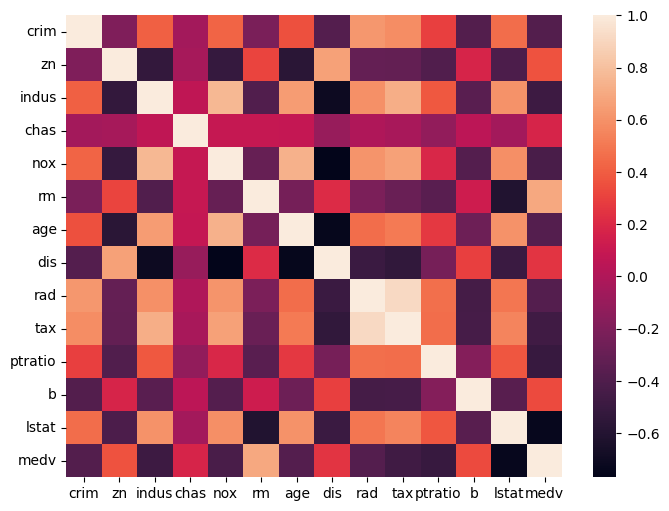

In [13]:
sns.heatmap(corr)

The lighter the color the higher positive correlation, the darker the color the higher the negative correlation will be.

In [14]:
X = housing_dataset.drop(["medv"], axis = 1)
y = housing_dataset.filter(["medv"], axis = 1)

Divide our data into features; denoted by variable X, and consists of all the columns except MEDV. Variable y consists of our labels, which only consists of the MEDV column.

In [15]:
X.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [16]:
 y.head()

,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

This splits the data into training and test sets. Inside our function train_test_split; test_size splits 20 percent of our data into the test group and the other 80 percent into the training set.

In [18]:
house_predictor = LinearRegression()
house_predictor.fit(X_train, y_train)
y_pred = house_predictor.predict(X_test)

The training sets are passed to the fit function in the LinearRegression Class. The test X variable test is passed into the predict method, where it will make prediction

In [21]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 3.189091965887837
Mean Squared Error: 24.291119474973478
Root Mean Squared Error: 4.928602182665332


Mean Absolute Error (MAE): Calculated by taking the average of absolute error obtained by find the sum of the absolute value of the subtraction of the real values from the predicted values and dividing by n.

Mean Squared Error (MSE): is the sum of the real values minus the predicted values squared and dividing by n.

Root Mean Squared Error (RMSE): Is taking the MSE and square rooting it.

The MAE value of 3.18 shows that there is an error of 3.18 dollars between the actual and predicted values.

In [22]:
comparison_df = pd.DataFrame({'Actual': y_test.values.tolist(), 'Predicted': y_pred.tolist()})
comparison_df

,Actual,Predicted
0,[23.6],[28.996723619824937]
1,[32.4],[36.02556533567226]
2,[13.6],[14.816944045388151]
3,[22.8],[25.031979150399454]
4,[16.1],[18.76987991524816]
...,...,...
97,[17.9],[-0.16423699568657568]
98,[9.6],[13.68486681528589]
99,[17.2],[16.183596971713442]
100,[22.5],[22.276219993533406]


Here we create a data frame; basically a table, that show the MEDV actual values compared to the predicted values created from the test group.

In [23]:
print(house_predictor.coef_)

[[-1.13055924e-01  3.01104641e-02  4.03807204e-02  2.78443820e+00
  -1.72026334e+01  4.43883520e+00 -6.29636221e-03 -1.44786537e+00
   2.62429736e-01 -1.06467863e-02 -9.15456240e-01  1.23513347e-02
  -5.08571424e-01]]


You can also print the linear regression coefficient, to see how algorithm is making predictions.

In [24]:
 X_test.values[1].shape

(13,)

This single record has one dimension

In [26]:
single_point = X_test.values[1].reshape(1,-1)
single_point.shape

(1, 13)

To make predictions on a single record, you need to reshape it. This code converts it into a row vector, that is what (1,-1) does.

In [28]:
house_predictor.predict(X_test.values[1].reshape(1,-1))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[36.02556534]])

Shows that our predicted value is 36.02 thousand for MEDV

In [29]:
y_test.values[1]

array([32.4])

So our predicted value is 36.02 thousand by the actual value is 32.4, meaning our prediction has an error of an estimated 4 thousand.